In [1]:
print('hi')

hi


In [2]:
from pydantic import BaseModel, Field
from typing import Annotated, Sequence, TypedDict, Literal
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import operator
from typing import List, TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import create_retriever_tool
from langsmith.client import Client

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
load_dotenv()
os.environ['OPENAI_API_KEY']=os.getenv('OPENAI_API_KEY')

In [4]:
llm=ChatOpenAI()
llm.invoke("What is the weather in Tokyo?")

AIMessage(content='The current weather in Tokyo is 76°F (24°C) with partly cloudy skies.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 14, 'total_tokens': 32, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DWhsZGhu38XmhIFRuAWYy72o4q58b', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019daad4-613f-7eb0-8f10-6c61f0ad069a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 18, 'total_tokens': 32, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
embeddings=OpenAIEmbeddings(
    model='text-embedding-3-large'
)

In [6]:
embeddings.embed_query("What is the weather in Tokyo?")

[-0.01090240478515625,
 -0.059539794921875,
 -4.8279762268066406e-05,
 0.038818359375,
 -0.019927978515625,
 -0.06427001953125,
 -0.011199951171875,
 -0.01348114013671875,
 -0.0294952392578125,
 -0.0283966064453125,
 -0.0029754638671875,
 0.0170440673828125,
 0.01055145263671875,
 0.029144287109375,
 0.003753662109375,
 0.017852783203125,
 0.004230499267578125,
 -0.009368896484375,
 0.0146026611328125,
 0.01364898681640625,
 -0.0291595458984375,
 0.01331329345703125,
 0.009674072265625,
 0.0185089111328125,
 -0.01334381103515625,
 0.01873779296875,
 0.0029048919677734375,
 -0.0004596710205078125,
 -0.007965087890625,
 -0.0203704833984375,
 0.0183258056640625,
 0.002819061279296875,
 0.032867431640625,
 0.0138092041015625,
 -0.0252838134765625,
 -0.0121612548828125,
 0.02850341796875,
 0.01187896728515625,
 0.0271759033203125,
 0.04974365234375,
 0.0104827880859375,
 0.00794219970703125,
 -0.0011730194091796875,
 0.001964569091796875,
 -0.0162506103515625,
 0.0123138427734375,
 0.015014

In [7]:
len(embeddings.embed_query("What is the weather in Tokyo?"))

3072

## AGENTIC RAG

In [8]:
url="https://lilianweng.github.io/posts/2023-06-23-agent/"

In [9]:
web_loader=WebBaseLoader(url)

In [10]:
data=web_loader.load()

In [11]:
data[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [12]:
data[0].page_content

'\n\n\n\n\n\nLLM Powered Autonomous Agents | Lil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\n\n\nComponent Three: Tool Use\n\nCase Studies\n\nScientific Discovery Agent\n\nGenerative Agents Simulation\n\nProof-of-Concept Examples\n\n\nChallenges\n\nCitation\n\nReferences\n\n\n\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The

In [13]:
urls=[
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/"    
]

In [14]:
docs=[WebBaseLoader(url).load() for url in urls]

In [15]:
docs

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final res

In [16]:
docs_list=[item for sublist in docs for item in sublist]

In [17]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [18]:
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100,
    chunk_overlap=25
)

In [19]:
doc_splits=text_splitter.split_documents(docs_list)

In [20]:
doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [21]:
from langchain_community.vectorstores import Chroma

In [22]:
vectorstore=Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag_collection",
    embedding=embeddings
)

In [23]:
retriever=vectorstore.as_retriever()

In [24]:
retriever.invoke("What is agent & prompt?")

[Document(metadata={'language': 'en', 'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/', 'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. At its core, the goal of prompt engineering is about alignment and model steerability. Check my previous post on controllable text generation.', 'title': "Prompt Engineering | Lil'Log"}, page_content='Automatic Prompt Design#'),
 Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/', 'description': 'Prompt Engineering, also known 

In [25]:
## Create the retriever into the tool
retriever_tool=create_retriever_tool(
    retriever,
    name="retriever_blog_post",
    description="A tool to retrieve information from the RAG collection about the LLM agents, prompt engineering, and other related topics"
)

In [26]:
tools=[retriever_tool]

In [27]:
retriever_node=ToolNode(tools=tools)

In [28]:
## Creating a Custom State

class AgentState(TypedDict):
    messages: Annotated[
        Sequence[BaseMessage],
        add_messages]
    

In [ ]:
from curses import REPORT_MOUSE_POSITION
from email import message


def llm_decision_maker(state: AgentState):
    print("<--------------- CALL LLM DECISION MAKER --------------->")
    messages=state["messages"]
    if len(message)>1:
        last_message=messages[-1]
        question=last_message.content
        prompt=PromptTemplate(template="")
        chain=prompt | llm
        chain.invoke({"question":question})
        return {"messages": [response]}
    else:
        llm_with_tool=llm.bind_tools(tools)
        response=llm_with_tool.invoke(message)
        return {"messages": [response]}

In [30]:
def grade_document(state: AgentState):
    pass

In [31]:
client = Client()

client.pull_prompt("rlm/rag-prompt")


ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [32]:
client.pull_prompt("rlm/rag-prompt").pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [33]:
class grade(BaseModel):
    binary_score:str = Field(description="relevance score, 'yes' or 'no'")

In [34]:
def generate(state:AgentState):
    pass
def rewrite(state:AgentState):
    pass

In [35]:
workflow=StateGraph(AgentState)

In [36]:
workflow.add_node("LLM Decision Maker", llm_decision_maker)
workflow.add_node("Vector Retriever", retriever_node)
workflow.add_node("Output Generator", generate)
workflow.add_node("Query Rewriter", rewrite)


In [37]:
workflow.add_edge(START, "LLM Decision Maker")

In [38]:
workflow.add_conditional_edges("LLM Decision Maker",
                 tools_condition,
                 {"tools": "Vector Retriever",
                 END:END})

In [39]:
workflow.add_conditional_edges("Vector Retriever",
                 grade_document,
                 {"generator": "Output Generator",
                 "rewriter": "Query Rewriter"})

In [40]:
workflow.add_edge("Output Generator", END)

In [41]:
workflow.add_edge("Query Rewriter", "LLM Decision Maker")

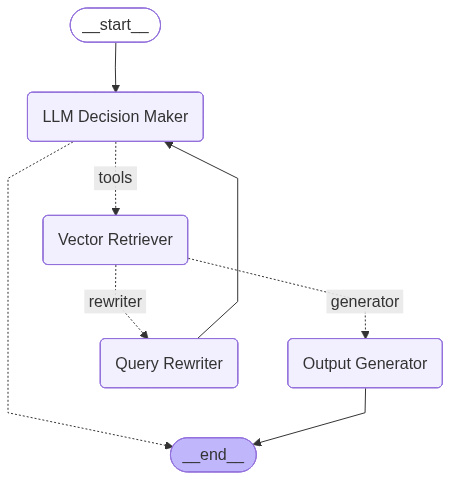

In [42]:
workflow.compile()